<a href="https://colab.research.google.com/github/huyd073003/AAI2026/blob/dev/Coding_Exercise_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Data source: Synthetic dataset generated earlier using NumPy (150+ rows).
# File created in this project: housing_price_dataset_with_location.csv
# Generate synthetic data if the file does not exist
try:
    df = pd.read_csv("housing_price_dataset_with_location.csv")
except FileNotFoundError:
    print("Generating synthetic data as 'housing_price_dataset_with_location.csv' was not found.")
    num_samples = 200
    np.random.seed(42) # for reproducibility

    square_footage = np.random.randint(1000, 3500, num_samples)
    locations = np.random.choice(['Downtown', 'Suburb', 'Rural'], num_samples, p=[0.4, 0.4, 0.2])
    # Simple price model: base price + square footage effect + location effect + noise
    base_price = 150000
    sf_effect = 100 # $100 per sq ft
    location_effect = {
        'Downtown': 50000,
        'Suburb': 20000,
        'Rural': -10000}
    noise = np.random.normal(0, 20000, num_samples)

    price = [base_price + sf * sf_effect + location_effect[loc] + n
             for sf, loc, n in zip(square_footage, locations, noise)]

    df = pd.DataFrame({
        'Square_Footage': square_footage,
        'Location': locations,
        'Price_USD': price
    })
    df.to_csv("housing_price_dataset_with_location.csv", index=False)
    print("Synthetic data generated and saved to 'housing_price_dataset_with_location.csv'.")


print("Rows:", len(df))
print(df.head())

# Features and target (match rubric: price, square footage, location)
X = df[["Square_Footage", "Location"]].rename(
    columns={"Square_Footage": "square_footage", "Location": "location"}
)
y = df["Price_USD"].rename("price")

# Preprocessing: One-hot encode the location column
preprocessor = ColumnTransformer(
    transformers=[
        ("location", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ["location"])
    ],
    remainder="passthrough"  # keeps square_footage
)
# Create pipeline with preprocessing and model
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())])
# Split data (as in your starter code)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
# Train model
model.fit(X_train, y_train);
# Make prediction for a new house: 2000 sq ft in Downtown
new_house = pd.DataFrame({"square_footage": [2000], "location": ["Downtown"]})
predicted_price = model.predict(new_house)
print(f"\nPredicted price for a 2000 sq ft house in Downtown: ${predicted_price[0]:,.2f}")
# Display model coefficients
# Get OneHotEncoder feature names + numeric feature name
location_feature_names = (
    model.named_steps["preprocessor"]
    .named_transformers_["location"]
    .get_feature_names_out(["location"])).tolist()

feature_names = location_feature_names + ["square_footage"]

coefficients = model.named_steps["regressor"].coef_
intercept = model.named_steps["regressor"].intercept_
print("\nModel Intercept:")
print(f"{intercept:,.2f}")
print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:,.2f}")

Rows: 150
   Square_Footage  Price_USD  Location
0            3674  593156.74    Suburb
1            1360  146734.23     Rural
2            1794  283759.01    Suburb
3            1630  241194.40    Suburb
4            1595  257903.32  Downtown

Predicted price for a 2000 sq ft house in Downtown: $294,395.76

Model Intercept:
1,301.64

Model Coefficients:
location_Downtown: -2,659.20
location_Rural: 3,108.25
location_Suburb: -449.06
square_footage: 147.88


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Dataset source: Synthetic dataset generated with NumPy for this assignment (250 records)

np.random.seed(42)

n = 250
regions = ["North", "South", "East", "West"]

age = np.random.randint(18, 75, size=n)
monthly_usage_hours = np.random.gamma(shape=2.0, scale=15.0, size=n)
monthly_usage_hours = np.clip(monthly_usage_hours, 0, 120)

purchase_amount = np.random.normal(loc=200, scale=80, size=n)
purchase_amount = np.clip(purchase_amount, 0, 600)

customer_service_calls = np.random.poisson(lam=2.5, size=n)
customer_service_calls = np.clip(customer_service_calls, 0, 15)

region = np.random.choice(regions, size=n, p=[0.25, 0.30, 0.20, 0.25])

region_effect = {"North": 0.05, "South": 0.10, "East": 0.00, "West": 0.08}
re = np.array([region_effect[r] for r in region])

score = (
    0.9 * (customer_service_calls / 5)
    - 0.8 * (monthly_usage_hours / 60)
    - 0.4 * (purchase_amount / 400)
    + 0.15 * ((age - 40) / 30)
    + re
)

churn_prob = 1 / (1 + np.exp(-score))
churn = (np.random.rand(n) < churn_prob).astype(int)

df = pd.DataFrame({
    "age": age,
    "monthly_usage_hours": monthly_usage_hours.round(1),
    "purchase_amount": purchase_amount.round(2),
    "customer_service_calls": customer_service_calls,
    "region": region,
    "churn": churn
})

X = df[["age", "monthly_usage_hours", "purchase_amount", "customer_service_calls", "region"]]
y = df["churn"]

numeric_features = ["age", "monthly_usage_hours", "purchase_amount", "customer_service_calls"]
categorical_features = ["region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

new_customer = pd.DataFrame({
    "age": [35],
    "monthly_usage_hours": [20],
    "purchase_amount": [150],
    "customer_service_calls": [5],
    "region": ["West"]
})

churn_probability = model.predict_proba(new_customer)[0][1]
threshold = 0.5
churn_prediction = 1 if churn_probability > threshold else 0

print(f"Churn Probability for new customer: {churn_probability:.2f}")
print(f"Churn Prediction (1 = churn, 0 = no churn): {churn_prediction}")

region_ohe_names = (
    model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(["region"])
).tolist()

feature_names = numeric_features + region_ohe_names
coefficients = model.named_steps["classifier"].coef_[0]

print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")


Churn Probability for new customer: 0.72
Churn Prediction (1 = churn, 0 = no churn): 1

Model Coefficients:
age: -0.08
monthly_usage_hours: -0.50
purchase_amount: -0.21
customer_service_calls: 0.30
region_East: -0.07
region_North: 0.41
region_South: -0.50
region_West: 0.16


In [9]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Dataset source: Synthetic customer dataset generated with NumPy (250 records)

np.random.seed(42)

n = 250
regions = ["North", "South", "East", "West"]

annual_spending = np.random.gamma(shape=2.5, scale=500, size=n)
purchase_frequency = np.random.poisson(lam=8, size=n)
age = np.random.randint(18, 70, size=n)
region = np.random.choice(regions, size=n)

df = pd.DataFrame({
    "annual_spending": annual_spending.round(2),
    "purchase_frequency": purchase_frequency,
    "age": age,
    "region": region
})

features = ["annual_spending", "purchase_frequency", "age"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(1, 6)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.savefig("elbow_plot.png")
plt.close()

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby("cluster")[features].mean().round(2)

print("Cluster Characteristics:")
print(cluster_summary)

for cluster in range(optimal_k):
    print(f"\nCluster {cluster} Strategy:")
    if cluster_summary.loc[cluster, "annual_spending"] > 1500:
        print("High-spending customers: Offer exclusive promotions or VIP loyalty rewards.")
    elif cluster_summary.loc[cluster, "purchase_frequency"] > 10:
        print("Frequent buyers: Provide subscription plans or bulk discounts.")
    else:
        print("Lower engagement customers: Send personalized re-engagement campaigns and targeted discounts.")

df.to_csv("customer_segments.csv", index=False)


Cluster Characteristics:
         annual_spending  purchase_frequency    age
cluster                                            
0                1015.87                8.81  29.69
1                2642.38                7.44  46.15
2                1038.95                7.19  55.32

Cluster 0 Strategy:
Lower engagement customers: Send personalized re-engagement campaigns and targeted discounts.

Cluster 1 Strategy:
High-spending customers: Offer exclusive promotions or VIP loyalty rewards.

Cluster 2 Strategy:
Lower engagement customers: Send personalized re-engagement campaigns and targeted discounts.



6-Step Housing Price Forecast (by Square Footage):
 square_footage  predicted_sales
           4416    550600.387645
           4516    563259.737155
           4616    575919.086666
           4716    588578.436176
           4816    601237.785686
           4916    613897.135196


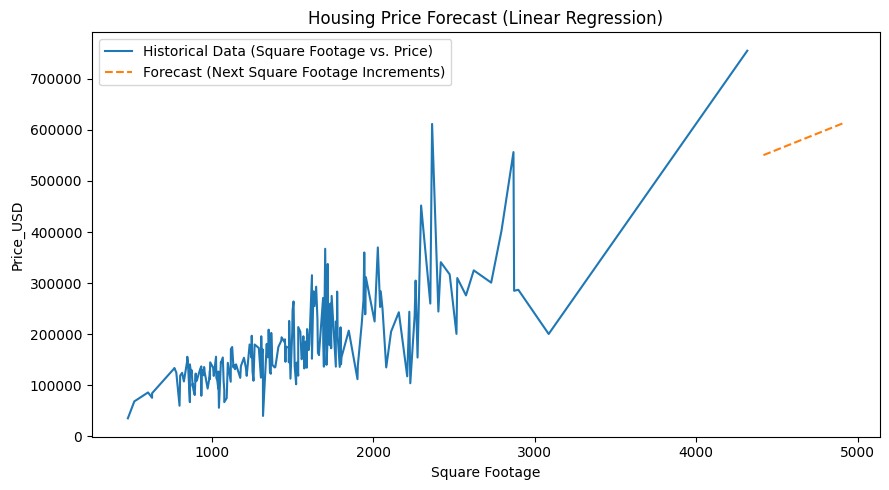

In [14]:
#extra credit
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/housing_from_huggingface_with_location.csv") # Changed to use the correct file

# Rename columns to fit the original code's expectations for 'month' and 'sales'
df = df.rename(columns={'square_footage': 'month', 'price': 'sales'}) # Corrected 'price_usd' to 'price' and explicitly reassigned

# Basic preprocessing
df = df.dropna(subset=["month", "sales"]).copy()
df["month"] = pd.to_numeric(df["month"], errors="coerce")
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df = df.dropna(subset=["month", "sales"]).sort_values("month")

# Features and target
X = df[["month"]]
y = df["sales"]

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 6 months (using 'month' which is now 'square_footage')
# For housing data, predicting 'next 6 months' is not directly applicable.
# Instead, we can predict prices for a range of square footages.
# Let's predict for a range of square footages based on the existing data range.
last_sf = int(df["month"].max())
# Let's predict for square footages increasing from the max observed to a reasonable upper bound, e.g., max_observed + 500*6 (if 'month' were 100s of sq ft).
# A more reasonable approach for housing data would be to predict for specific square footages.
# For consistency with the original code structure (predicting 'next 6'), let's simulate a future range.
# If 'month' represents square footage, let's predict for 6 different square footages above the current max.
future_square_footages = pd.DataFrame({"month": range(last_sf + 100, last_sf + 601, 100)}) # Predicting for 6 square footage increments
predictions = model.predict(future_square_footages)

# Output forecast table
forecast_df = future_square_footages.copy()
forecast_df["predicted_sales"] = predictions
print("\n6-Step Housing Price Forecast (by Square Footage):")
# Rename 'month' back to 'square_footage' for clarity in output
forecast_df.rename(columns={'month': 'square_footage'}, inplace=True)
print(forecast_df.to_string(index=False))

# Plot results
plt.figure(figsize=(9, 5))
plt.plot(df["month"], y, label="Historical Data (Square Footage vs. Price)")
plt.plot(future_square_footages["month"], predictions, label="Forecast (Next Square Footage Increments)", linestyle="--")
plt.xlabel("Square Footage") # Updated label
plt.ylabel("Price_USD") # Updated label
plt.title("Housing Price Forecast (Linear Regression)") # Updated title
plt.legend()
plt.tight_layout()
plt.show()